In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from konlpy.tag import Okt
import cx_Oracle
from sqlalchemy import create_engine
import os
from PIL import Image

In [2]:
okt = Okt()

In [3]:
stopwords = ['투자', '주가', '주식', '가능성', '거래', '보고', '수익', '오늘', '사람', '시장',
             '올해', '내년', '국내', '해외', '기업', '실적', '성장', '매출', '영업', '기대',
             '손실', '차트', '분석', '정보', '데이터', '종목', '변동', '영향', '변화', '예측']


In [4]:
# 🔹 Oracle DB 연결 (SQLAlchemy 사용)
db_user = "c##PROJECT"
db_password = "k5002"
db_host = "localhost"
db_port = "1521"
db_service = "xe"

In [5]:
engine = create_engine(f"oracle+cx_oracle://{db_user}:{db_password}@{db_host}:{db_port}/?service_name={db_service}")

In [7]:
# 🔹 DB에서 뉴스와 커뮤니티 토큰 데이터 가져오기
query = """
    SELECT NEWS_TOKEN FROM NEWS
    UNION ALL
    SELECT CONTENT_TOKEN FROM COMMUNITY
"""
df = pd.read_sql(query, con=engine)

In [8]:
df = df.dropna()
text_data = ' '.join(df.iloc[:, 0]) 

In [9]:
# 🔹 명사 추출 함수
def extract_nouns(text):
    nouns = okt.nouns(text)  # 명사 추출
    return ' '.join(nouns)  # 공백으로 연결하여 반환

In [10]:
# 🔹 명사 추출 및 불용어 제거
text_data = extract_nouns(text_data)
words = text_data.split()
filtered_words = [word for word in words if word not in stopwords]
word_counts = Counter(filtered_words)

In [35]:
# ✅ 올바른 이미지 저장 경로 (`finalproject/fastapi/app/images/wordcloud`)
BASE_DIR = os.getcwd()
IMAGE_DIR = os.path.join(BASE_DIR, "..", "fastapi", "app", "images", "wordcloud")  # ✅ 경로 변경
os.makedirs(IMAGE_DIR, exist_ok=True)  # 폴더가 없으면 생성

# ✅ 마스크 이미지 경로 설정
circle_mask_path = os.path.join(IMAGE_DIR, "circle_mask.png")

In [11]:
# 🔹 워드 클라우드 생성
font_path = r'C:\Windows\Fonts\malgun.ttf'  # 한글 폰트 경로 (Windows 기준)
wordcloud = WordCloud(
    font_path=font_path,
    width=300, height=300,
    background_color='white',
    max_words=50,
    min_font_size=10,  # ✅ 최소 글자 크기 조정
    max_font_size=50,  # ✅ 최대 글자 크기 제한
    min_word_length=2,
    random_state=2024,
    # mask=circle_mask  # ✅ 원형 마스크 적용
).generate_from_frequencies(word_counts)

In [40]:
wordcloud_path = os.path.join(IMAGE_DIR, "wordcloud.png")
wordcloud.to_file(wordcloud_path)
print(f"✅ 워드 클라우드가 저장되었습니다: {wordcloud_path}")

✅ 워드 클라우드가 저장되었습니다: d:\kdt\finalproject\wordcloud\..\fastapi\app\images\wordcloud\wordcloud.png


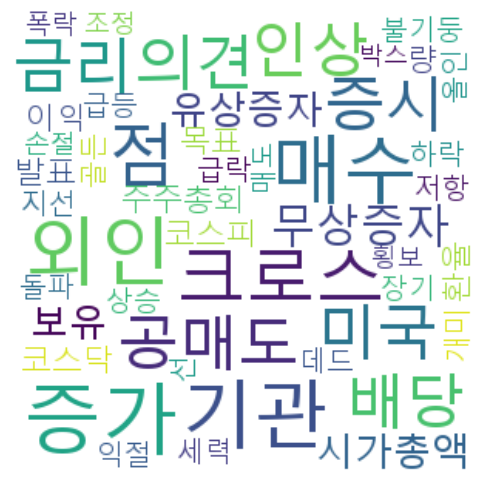

In [12]:
# 🔹 워드 클라우드 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [13]:
# 🔹 상위 50개 단어 출력
print("\n🔹 상위 5 카운트 단어")
for word, count in word_counts.most_common(5):
    print(f"{word}: {count}")


🔹 상위 5 카운트 단어
증가: 1545
외인: 1397
기관: 1385
매수: 1384
점: 1205


In [ ]:
# 상위 다섯개 단어 딕셔너리

top_5_words = Counter(dict(word_counts.most_common(5)))
print(top_5_words)

Counter({'증가': 1508, '매수': 1381, '외인': 1362, '기관': 1341, '크로스': 1276})


In [50]:
from sqlalchemy import create_engine, text

In [ ]:
# 🔹 데이터 삽입 함수
def insert_top_words(engine, top_5_words):
    try:
        with engine.connect() as connection:
            # 기존 데이터 삭제
            connection.execute(text("DELETE FROM TOP_WORDS"))

            # 새로운 데이터 삽입
            for word, count in word_counts.items():
                connection.execute(
                    text("INSERT INTO TOP_WORDS (WORD, COUNT, CDATE) VALUES (:word, :count, SYSTIMESTAMP)"),
                    {"word": word, "count": count}
                )

            connection.commit()
            print("✅ 데이터 삽입 완료!")

    except Exception as e:
        print("❌ 데이터 삽입 실패:", e)

# 실행
insert_top_words(engine, top_5_words)


✅ 데이터 삽입 완료!
